# **Processing fluxomics & proteomics data from ECOMICS**

This notebook processes the ECOMICS dataset. 

ECOMICS is a comprehensive multi-omics resource for *Escherichia coli*, developed to enable predictive modeling of cellular states. It recovers 4,389 genome-wide profiles from 65 *E. coli* K-12 strains, 286 genetic perturbations, and 112 media conditions. 

The fluxomcis accounts for 43 profiles of 120 metabolic fluxes, and normalizes the values using the glucose uptake rate of each specific study. The fluxomics data can be found in `data/raw/ECOMICS/fluxomics_ecomics.csv`

The proteomics 

---
Kim, M., Rai, N., Zorraquino, V., & Tagkopoulos, I. (2016). Multi-omics integration accurately predicts cellular state in unexplored conditions for Escherichia coli. Nature Communications, 7(1). https://doi.org/10.1038/ncomms13090

## 1. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Add paths
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../scripts'))

# Add directories
data_dir = "../data"

raw_data_dir = os.path.join(data_dir, "raw")
ecomics_raw_dir = os.path.join(raw_data_dir, "ECOMICS")

processed_data_dir = os.path.join(data_dir, "processed")
ecomics_processed_dir = os.path.join(processed_data_dir, "ECOMICS")

ecomics_final_dir = os.path.join(data_dir, "final", "ECOMICS")

# **Fluxomics**

## 2. Create a GEM reaction dataframe

In [2]:
from scripts.enzyme_classifier import create_gem_rxns_df


from cobra.io import read_sbml_model
import cobra 
cobra.Configuration().solver = "cplex"

model = cobra.io.read_sbml_model(os.path.join(raw_data_dir,"GEMs","iML1515_GEM.xml"))
df_rxns = create_gem_rxns_df(model)
processed_data_dir = os.path.join(data_dir, "processed")

#df_rxns.to_csv(ecomics_processed_dir, index=False)

## 3. Matching ECOMICS to iML1515 reactions

In [3]:
import pandas as pd
import cobra

# Load ECOMICS and iML1515 rxns dataframes
eco_path = os.path.join(raw_data_dir, "ECOMICS", "ecomics_rxns.csv")
eco = pd.read_csv(eco_path)

iml_path = os.path.join(ecomics_processed_dir, "iml1515_rxns.csv")
iml = pd.read_csv(iml_path)

# Manual correction of PDHm --> PDH
eco.loc[eco["bigg_id"] == "PDHm", "bigg_id"] = "PDH"

# Manual correction EX_succ(e) --> EX_succ_e
eco.loc[eco["bigg_id"] == "EX_succ(e)", "bigg_id"] = "EX_succ_e"

# Initialize list to map rxns between ecomics and gem
matches = []

for _, row in eco.iterrows():
    # Exact BiGG hit
    hit = iml.loc[iml["gem_bigg"] == row["bigg_id"]]

   # Empty row is no match
    if hit.empty:
        matches.append({
            "gem_rxn": pd.NA,
            "gem_rxn_id": pd.NA
        })
    else:
        h = hit.iloc[0]
        matches.append({
            "gem_rxn": h["gem_rxn"],
            "gem_rxn_id": h["gem_rxn_id"]
        })

# Final df that is the length of the ECOMICS rxns
eco_out = eco.join(pd.DataFrame(matches))
print(eco_out.shape)
print(eco_out.head())

(115, 5)
  ecomics_rxn_id                 ecomics_rxn   bigg_id  \
0          R0001  Glucose + PEP -> G6P + PYR  GLCptspp   
1          R0002                 G6P <-> F6P       PGI   
2          R0003                F6P -> F1,6P       PFK   
3          R0004         F1,6P -> DHAP + G3P       FBA   
4          R0005                 DHAP -> G3P       TPI   

                                 gem_rxn gem_rxn_id  
0     glc__D_p + pep_c --> g6p_c + pyr_c   GLCptspp  
1                        g6p_c <=> f6p_c        PGI  
2  atp_c + f6p_c --> adp_c + fdp_c + h_c        PFK  
3               fdp_c <=> dhap_c + g3p_c        FBA  
4                       dhap_c <=> g3p_c        TPI  


In [4]:
# Df with the successful BiGG matches
eco_out_hits = eco_out[eco_out['gem_rxn_id'].notna()]
print(eco_out_hits.shape)

(26, 5)


In [5]:
# Df with NO BiGG matches
eco_out_misses = eco_out[eco_out['gem_rxn_id'].isna()]
print(eco_out_misses.shape)

# Exporting for manual curation
eco_out_misses_csv = eco_out_misses.iloc[:, [0, 1]]
eco_out_misses_path = os.path.join(ecomics_processed_dir, "eco_out_misses.csv")
#eco_out_misses_csv.to_csv(eco_out_misses_path, index=False)

(89, 5)


## 4. Manual curation of ECOMICS reactions

### Manual curation 

*Goal:* to map the reactions in the ECOMICS dataset without a BiGG ID. 

To do this, we'll look at each reaction in the unnanotated ECOMICS (**eco_out_misses**), and look for the best fit considering all of the reactions in the iML1515 GEM (**df_rxns**).

To make the process more efficient **eco_out_misses** and **df_rxns** were uploaded to NotebookLM, and prompted to find the best fit between these datasets.

Some mappings were direct, while others involved a combination of multiple sequential reactions into a single, more generalized reaction. Additionally, the level of detail differed, such as the inclusion of cofactors in the GEM reactions (e.g. ATP, ADP, NAD).

The final manually curated dataframe will have multiple iML1515 rxns mapped to a single ECOMICS rxn ID. Distributing this flux across the participant reactions remains pendant. Some ideas include:
- Choose a single best fitting reaction after the FBA simulations, where the GEM rxn with closest simulated flux to the experimental will be kept.
- Distribute the flux across all participating rxns (TBD how - possibly w a directed graph) 

In [6]:
# Manually curated dataframe
eco_curated_path = os.path.join(ecomics_processed_dir, "eco_out_misses_curated.csv")
eco_curated = pd.read_csv(eco_curated_path)

# Concatenate the curated df w the hits df
eco_curated_hits = pd.concat([eco_curated, eco_out_hits])

# Check the lenghts
print(f"eco curated: {eco_curated.shape}")
print(f"eco hits: {eco_out_hits.shape}")
print(f"eco curated + hits: {eco_curated_hits.shape}")

eco curated: (187, 5)
eco hits: (26, 5)
eco curated + hits: (213, 6)


In [7]:
# Order the rows using ecomics_rxn_id
eco_curated_hits = eco_curated_hits.sort_values(by='ecomics_rxn_id')

# Fill the bigg_id column using the gem_rxn_id
eco_curated_hits['bigg_id'] = eco_curated_hits['bigg_id'].fillna(eco_curated_hits['gem_rxn_id'])

# Create a mapping dictionary from df_rxns
rxn_mapping = df_rxns.set_index('gem_rxn_id')['gem_rxn'].to_dict()

# Fill the gem_rxn column using the mapping
eco_curated_hits['gem_rxn'] = eco_curated_hits['gem_rxn'].fillna(
    eco_curated_hits['gem_rxn_id'].map(rxn_mapping)
)

eco_curated_hits_missing = eco_curated_hits[eco_curated_hits['gem_rxn_id'].isna()]
print('Number reactions without a gem match: ', len(eco_curated_hits_missing))
print(f"eco curated + hits - missing: {eco_curated_hits.shape[0]-len(eco_curated_hits_missing)}")

Number reactions without a gem match:  20
eco curated + hits - missing: 193


In [8]:
# Load complete ECOMICS fluxomics dataframe
ecomicsfluxes_path = os.path.join(ecomics_raw_dir, "fluxomics_ecomics.csv")
ecomicsfluxes = pd.read_csv(ecomicsfluxes_path)

print(f"Original fluxomics shape: {ecomicsfluxes.shape}")
print('Total fluxes: ', ecomicsfluxes.shape[1]-4)
print('Total conditions: ', ecomicsfluxes.shape[0])
print(ecomicsfluxes.head())



Original fluxomics shape: (43, 124)
Total fluxes:  120
Total conditions:  43
    Strain MediumID         Medium Stress  R0001  R0002  R0003  R0004  R0005  \
0  BW25113    MD066  synthetic+Glu   none    100   63.0   79.0   79.0   79.0   
1  BW25113    MD066  synthetic+Glu   none    100   62.0   80.0   80.0   80.0   
2    W3110    MD121         M9+Glu   none    100   73.0   83.1   83.1   83.1   
3  BW25113    MD066  synthetic+Glu   none    100   78.0   79.0   79.0   79.0   
4  BW25113    MD066  synthetic+Glu   none    100   63.0   80.0   80.0   80.0   

   R0006  ...  R0111  R0112  R0113  R0114  R0115  R0116  R0117  R0118  R0119  \
0  165.0  ...    0.0    0.0      0    0.0    0.0    0.0    0.0    0.0    0.0   
1  167.0  ...    0.0    0.0      0    0.0    0.0    0.0    0.0    0.0    0.0   
2  171.5  ...   71.2   69.0      0  113.4   27.2   10.1    7.5    9.0    0.9   
3  171.0  ...    0.0    0.0      0    0.0    0.0    0.0    0.0    0.0    0.0   
4  168.0  ...    0.0    0.0      0    0.0 

In [9]:
from collections import defaultdict

# Select first 4 metadata cols
metadata_cols = ecomicsfluxes.columns[:4]

# Create extended reaction names in eco_curated_hits
eco_curated_hits['extended_rxn_id'] = eco_curated_hits['ecomics_rxn_id'] + '_' + eco_curated_hits['gem_rxn_id']

# Drop rows where extended_rxn_id is NaN --> this avoiuds a bug in the next cleaning steps
eco_curated_hits_clean = eco_curated_hits.dropna(subset=['extended_rxn_id'])

# Create a mapping from original ecomics_rxn_id to list of extended reaction names
ecomics_to_extended = defaultdict(list)

for _, row in eco_curated_hits_clean.iterrows():
    ecomics_to_extended[row['ecomics_rxn_id']].append({
        'extended_name': row['extended_rxn_id'],
        'gem_rxn_id': row['gem_rxn_id']
    })

# Find reaction columns that have mappings
matched_rxn_cols = [col for col in ecomicsfluxes.columns if col in ecomics_to_extended]

# Create expanded flux dataframe
expanded_flux_data = {}

# Copy original flux values to extended reaction columns
for ecomics_rxn in matched_rxn_cols:
    original_flux_values = ecomicsfluxes[ecomics_rxn]
    
    # For each extended reaction mapping
    for mapping in ecomics_to_extended[ecomics_rxn]:
        extended_name = mapping['extended_name']
        # Duplicate the original flux values
        expanded_flux_data[extended_name] = original_flux_values

# Create the expanded dataframe
expanded_fluxes_df = pd.DataFrame(expanded_flux_data)
print(expanded_fluxes_df.shape)

(43, 192)


In [10]:
# Combine metadata and expanded fluxes
ecomicsfluxes_mapped = pd.concat([ecomicsfluxes[metadata_cols], expanded_fluxes_df], axis=1)

print('ECOMICS fluxes: ', ecomicsfluxes.shape[1]-4)
print(f"Fluxes mapped: {len(expanded_flux_data)}")

ecomicsfluxes_mapped.to_csv(os.path.join(ecomics_processed_dir, "fluxomics_ecomics_mapped.csv"), index=False)

ECOMICS fluxes:  120
Fluxes mapped: 192


## 5. Inspect most complete studies in ECOMICS

In [11]:
from scripts.ECOMICS_analysis import select_most_complete_study

# Check the most complete study - with the most non-zero fluxes
completeness_df = select_most_complete_study(ecomicsfluxes_mapped)
completeness_df = completeness_df.sort_values(by='num_nonzero_rxns', ascending=False)
print(completeness_df.head())

     Strain MediumID         Medium Stress  num_nonzero_rxns  \
2     W3110    MD121         M9+Glu   none               170   
39    W3110    MD121         M9+Glu   none               170   
20    W3110    MD121         M9+Glu   none               170   
14  BW25113    MD066  synthetic+Glu   none                39   
22  BW25113    MD066  synthetic+Glu   none                39   

    R0001_EX_glc__D_e  R0001_GLCptspp  R0002_PGI  R0003_PFK  R0004_FBA  ...  \
2                 100             100       73.0       83.1       83.1  ...   
39                100             100       77.5       84.0       84.0  ...   
20                100             100       73.0       83.4       83.4  ...   
14                100             100       67.0       69.0       69.0  ...   
22                100             100        0.0       34.0       34.0  ...   

    R0112_ACONTb  R0112_ACONTa  R0113_ICDHyr  R0114_SUCOAS  R0115_SUCOAS  \
2           69.0          69.0             0         113.4      

#### *OBSERVATION:* W3110 M9+Glu none is the most complete study (Crown et al., 2015)
- Using the study index 20, as it's the one that exactly matches the data in their fluxes csv.
- The original data can be found in `\misc\data\Crown_fluxomics.csv`

**TO DO:** Check what the rest of the W3110 M9+Glu none studies mean.

In [12]:
# We'll be working with the W3110 M9+Glu none study index 20
exp_fluxomics_df = ecomicsfluxes_mapped.iloc[20].to_frame('exp_flux')

In [13]:
condition_string = '_'.join(exp_fluxomics_df.iloc[:4, 0].astype(str).values) 
exp_fluxomics_df = exp_fluxomics_df.iloc[4:] # discard the first 4 rows (metadata)
exp_fluxomics_df = exp_fluxomics_df.reset_index().rename(columns={'index': 'exp_reaction'})

print(f'shape before removing 0 fluxes: {exp_fluxomics_df.shape}')
exp_fluxomics_df = exp_fluxomics_df[exp_fluxomics_df['exp_flux'] != 0]
print(f'shape after removing 0 fluxes: {exp_fluxomics_df.shape}')

exp_fluxomics_df.to_csv(os.path.join(ecomics_processed_dir, f"fluxomics_{condition_string}.csv"), index=False)
print(f'Created fluxomics dataframe for {condition_string}')

shape before removing 0 fluxes: (192, 2)
shape after removing 0 fluxes: (170, 2)
Created fluxomics dataframe for W3110_MD121_M9+Glu_none


## 6. Exchange fluxes
The ECOMICS data includes rates of consumption and secretion of glucose, oxygen, CO2, etc. 

These must be set to fixed reaction flux values in the GEM simulations.

*TO DO:* Right now it sets the bounds, but doesn't fix the flux values. Check what's better - setting bounds or fixing fluxes?

In [14]:
# Print model media
for key, value in model.medium.items():
    print(f"{key}: {value}")

EX_pi_e: 1000.0
EX_h_e: 1000.0
EX_fe3_e: 1000.0
EX_mn2_e: 1000.0
EX_co2_e: 1000.0
EX_fe2_e: 1000.0
EX_glc__D_e: 10.0
EX_zn2_e: 1000.0
EX_mg2_e: 1000.0
EX_ca2_e: 1000.0
EX_ni2_e: 1000.0
EX_cu2_e: 1000.0
EX_cobalt2_e: 1000.0
EX_sel_e: 1000.0
EX_h2o_e: 1000.0
EX_nh4_e: 1000.0
EX_mobd_e: 1000.0
EX_so4_e: 1000.0
EX_k_e: 1000.0
EX_na1_e: 1000.0
EX_o2_e: 1000.0
EX_cl_e: 1000.0
EX_tungs_e: 1000.0
EX_slnt_e: 1000.0


### **Manual matching ECOMICS reactions to their corresponding iML1515 exchanges**

The glucose uptake is normalized to 100 for all studies: 
- R001, Glucose + PEP -> G6P + PYR, glucose uptake: EX_glc__D_e

These specific rxns correspond to the Crown et al. (2015) study:
- R0102, CO2 -> CO2.Ext, CO2 secretion: EX_co2_e
- R0103, O2.Ext -> O2, 02 uptake: EX_o2_e
- R0104, NH3.Ext -> NH3, ammonia uptake: EX_nh4_e
- R0105, SO4.Ext -> SO4, sulfate uptake: EX_so4_e

These specific rxns correspond to the Ishii et al. (2007) study. They remain as ambiguous, but might be linked to these reactions:
- R0051, Glucose consumption rate: EX_glc__D_e
- R0052, Oxygen uptake rate (OUR): EX_o2_e
- R0053, Carbon dioxide evolution rate (CER): EX_co2_e

In [15]:
#  Make a copy of the original ECOMICS fluxes df
fixed_fluxes_df = ecomicsfluxes.copy()

In [16]:
# Mapping of reaction IDs to new names
reaction_rename_map = {
    'R0001': 'EX_glc__D_e',
    'R0101': 'EX_ac_e',
    'R0102': 'EX_co2_e',
    'R0103': 'EX_o2_e',
    'R0104': 'EX_nh4_e',
    'R0105': 'EX_so4_e'
}

# Rename the columns
fixed_fluxes_df.rename(columns=reaction_rename_map, inplace=True)

In [17]:
# Columns to keep: first four metadata columns + renamed reaction columns
metadata_columns = fixed_fluxes_df.columns[:4].tolist()
renamed_columns = list(set(reaction_rename_map.values()))
columns_to_keep = metadata_columns + renamed_columns

# Filter the dataframe
fixed_fluxes_df = fixed_fluxes_df[columns_to_keep]

In [18]:
fixed_fluxes_df.to_csv(os.path.join(ecomics_processed_dir, "fluxomics_ecomics_medium.csv"), index=False)

In [19]:
# Define the condition
# We'll be working with the W3110 M9+Glu none study
condition_string = 'W3110_MD121_M9+Glu_none'

# Select the row based on the condition string
condition_parts = condition_string.split('_')
filtered_row = fixed_fluxes_df[
    (fixed_fluxes_df['Strain'] == condition_parts[0]) &
    (fixed_fluxes_df['MediumID'] == condition_parts[1]) &
    (fixed_fluxes_df['Medium'] == condition_parts[2]) &
    (fixed_fluxes_df['Stress'] == condition_parts[3])
]

# Discard the first four columns
filtered_row = filtered_row.iloc[:, 4:]

# Transform into a new DataFrame
exp_fixed_flux_df = pd.DataFrame({
    'rxn_id': filtered_row.columns,
    'exp_fixed_flux': filtered_row.iloc[0].values
})

# Drop the rows where the flux is 0 --> these are actually NaN values
exp_fixed_flux_df = exp_fixed_flux_df[exp_fixed_flux_df['exp_fixed_flux'] != 0]

exp_fixed_flux_df.to_csv(os.path.join(ecomics_processed_dir, f"medium_{condition_string}.csv"), index=False)

In [20]:
print(exp_fixed_flux_df)

        rxn_id  exp_fixed_flux
0     EX_nh4_e            50.1
1     EX_co2_e           175.2
2      EX_ac_e            69.6
3      EX_o2_e           158.6
4  EX_glc__D_e           100.0
5     EX_so4_e             1.7


## 7. Apply ECOMICS conditions to the iML1515 GEM

In [21]:
from scripts.ECOMICS_analysis import apply_ecomics_condition

modified_model = apply_ecomics_condition("MD121", "none")

Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_o2_e lower bound to -15.86
Set EX_co2_e lower bound to 17.52
Set EX_h2o_e lower bound to -6.96


## 8. Reconciling fluxes -- wip

## 9. Comparison of fluxomics: ECOMICS vs FBA vs pFBA

In [22]:
from scripts.ECOMICS_analysis import create_fluxomics_dataframe

condition_string = 'W3110_MD121_M9+Glu_none'
exp_fluxes_path = os.path.join(ecomics_processed_dir, f"fluxomics_{condition_string}.csv")

fba_exp_df = create_fluxomics_dataframe('FBA', exp_fluxes_path, modified_model)
pfba_exp_df = create_fluxomics_dataframe('pFBA', exp_fluxes_path, modified_model)

FBA status: optimal
Multiple experimental reactions found for SHK3Dr: ['R0091_SHK3Dr', 'R0092_SHK3Dr'], used R0091_SHK3Dr
Multiple experimental reactions found for PSCVT: ['R0091_PSCVT', 'R0092_PSCVT'], used R0091_PSCVT
Multiple experimental reactions found for CHORS: ['R0091_CHORS', 'R0092_CHORS'], used R0091_CHORS
Multiple experimental reactions found for FBA: ['R0004_FBA', 'R0059_FBA'], used R0004_FBA
Multiple experimental reactions found for DHQTi: ['R0091_DHQTi', 'R0092_DHQTi'], used R0091_DHQTi
Multiple experimental reactions found for TALA: ['R0047_TALA', 'R0066_TALA', 'R0067_TALA'], used R0066_TALA
Multiple experimental reactions found for TKT1: ['R0014_TKT1', 'R0046_TKT1', 'R0065_TKT1'], used R0014_TKT1
Multiple experimental reactions found for FUM: ['R0022_FUM', 'R0063_FUM'], used R0022_FUM
Multiple experimental reactions found for THRD: ['R0082_THRD', 'R0090_THRD'], used R0090_THRD
Multiple experimental reactions found for DDPA: ['R0091_DDPA', 'R0092_DDPA'], used R0091_DDPA


### *TO CHECK:* 
- To handle the selection in the 'Multiple experimental reactions', I'm keeping the experimental flux that is closest to the simulations

## 10. Correct flux sign of experimental reactions

Many experimental reactions (suck as R0001 for glucose uptake) are missing the negative sign that indicates uptake rates in a GEM.

These are identified and corrected by comparing the sign of each reaction flux to those obtained with FBA.

In [23]:
from scripts.ECOMICS_analysis import correct_reversible_reactions

fba_exp_df = correct_reversible_reactions(fba_exp_df, 'FBA_flux')
pfba_exp_df = correct_reversible_reactions(pfba_exp_df, 'pFBA_flux')


### Up to this point, the dataframe is ready to be comparable to a GEM

In [24]:
# Clean and export to csv --> This is the dataframe used for kinGEMs
exp_df_kinGEMs = fba_exp_df.copy()
exp_df_kinGEMs.drop(columns=['FBA_flux'], inplace=True)
exp_df_kinGEMs.dropna(inplace=True)
exp_df_kinGEMs.to_csv(os.path.join(ecomics_final_dir, "fluxes_exp_kinGEMs.csv"), index=False)

## 8. Analyze experimental fluxes vs FBA & pFBA

### Results FBA

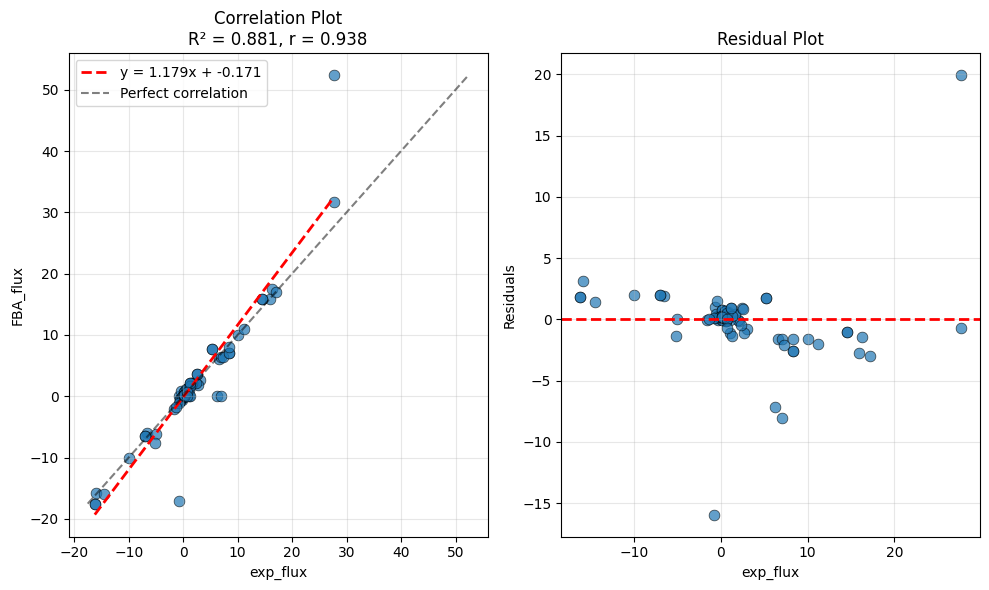

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs FBA_flux

STATISTICAL SUMMARY:
--------------------
total_reactions: 2712
reactions_with_both_values: 143
reactions_missing_method1: 2569
reactions_missing_method2: 0
mean_absolute_difference: 0.726376
median_absolute_difference: 0.110000
std_absolute_difference: 2.593054
mean_relative_difference: 0.596745
median_relative_difference: 0.102385
max_absolute_difference: 24.721169
min_absolute_difference: 0.000000

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.938422
pearson_p: 0.000000
spearman_r: 0.863756
spearman_p: 0.000000
r_squared: 0.880637
slope: 1.179422
intercept: -0.171450
n_points: 143

TOP REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES (exp_flux vs FBA_flux):
--------------------------------------------------
ATPS4rpp: 27.660000 vs 52.381169 (diff: 24.721169)
PGK: -0.810000 vs -17.072376 (diff: 16.262376)
ACt4pp: 6.990000 vs 0.000000 (diff: 6.990000)
NADTRHD: 6.200000 vs 0.000000 (diff: 6.200000)
CYTBO3_4pp: 27.66000

In [25]:
from scripts.flux_analysis_module import FluxAnalyzer

analyzer = FluxAnalyzer(fba_exp_df, 'exp_flux', 'FBA_flux', 'rxn_id')
analyzer.correlation_analysis()
analyzer.generate_report()

# Get outliers analysis including the sorted dataframe
results_analyzer = analyzer.identify_outliers(top_n=20, method='absolute')
sorted_df_FBA = results_analyzer['sorted_df']

In [26]:
sorted_df_FBA.to_csv(os.path.join(ecomics_final_dir, "exp_vs_FBA.csv"), index=False)

### Results pFBA

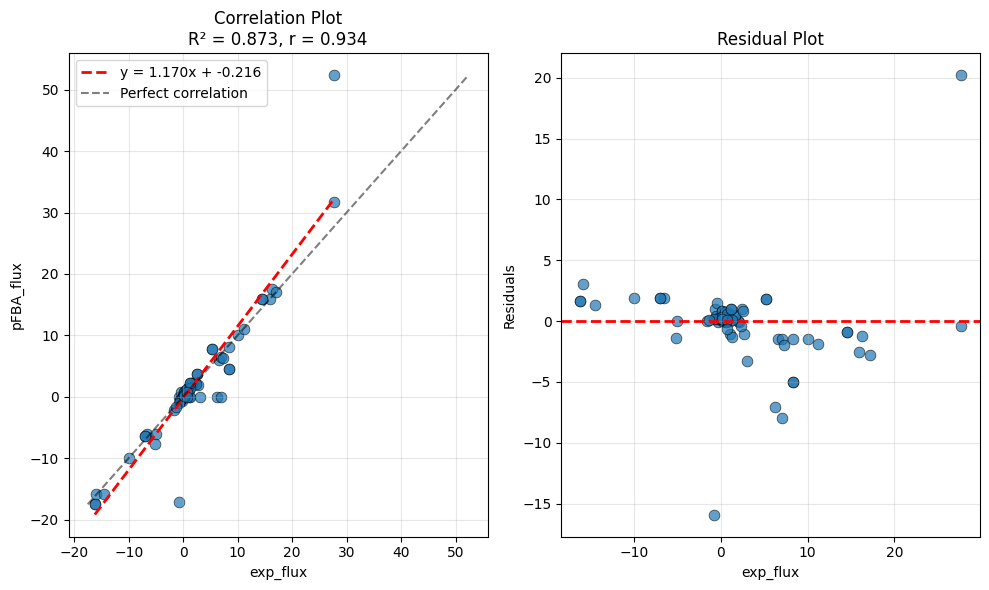

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs pFBA_flux

STATISTICAL SUMMARY:
--------------------
total_reactions: 2712
reactions_with_both_values: 143
reactions_missing_method1: 2569
reactions_missing_method2: 0
mean_absolute_difference: 0.777722
median_absolute_difference: 0.100648
std_absolute_difference: 2.625337
mean_relative_difference: 0.599067
median_relative_difference: 0.094548
max_absolute_difference: 24.721169
min_absolute_difference: 0.000000

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.934351
pearson_p: 0.000000
spearman_r: 0.848379
spearman_p: 0.000000
r_squared: 0.873012
slope: 1.170293
intercept: -0.216050
n_points: 143

TOP REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES (exp_flux vs pFBA_flux):
--------------------------------------------------
ATPS4rpp: 27.660000 vs 52.381169 (diff: 24.721169)
PGK: -0.810000 vs -17.072376 (diff: 16.262376)
ACt4pp: 6.990000 vs 0.000000 (diff: 6.990000)
NADTRHD: 6.200000 vs 0.000000 (diff: 6.200000)
CYTBO3_4pp: 27.660

In [27]:
from scripts.flux_analysis_module import FluxAnalyzer

analyzer = FluxAnalyzer(pfba_exp_df, 'exp_flux', 'pFBA_flux', 'rxn_id')
analyzer.correlation_analysis()
analyzer.generate_report()

# Get outliers analysis including the sorted dataframe
results_analyzer = analyzer.identify_outliers(top_n=20, method='absolute')
sorted_df_pFBA = results_analyzer['sorted_df']

In [28]:
sorted_df_pFBA.to_csv(os.path.join(ecomics_final_dir, "exp_vs_pFBA.csv"), index=False)

# **GEM fluxomics and proteomics**

## 8. Create enzymes dataframe

In [478]:
# Module imports
from scripts.enzyme_classifier import create_gpr_dataframe, analyze_model_gprs

from cobra.io import load_model
import cobra 

# Load the model
model = load_model("iML1515")

# Create a dataframe of the GPR rules
df_enzymes = create_gpr_dataframe(model)

# Analyze the model
stats = analyze_model_gprs(model)
print(f"\nModel Stats:")
print(f"Total reactions: {stats['total_reactions']}")
print(f"Reactions with GPR: {stats['reactions_with_gpr']}")
print(f"Total genes: {stats['total_genes']}")
print(f"GPR cases: {stats['gpr_complexity']}")


Model Stats:
Total reactions: 2712
Reactions with GPR: 2266
Total genes: 1516
GPR cases: {'simple': 1302, 'or_only': 651, 'and_only': 221, 'complex': 92}


## 9. Filter enzymes dataframe for fluxomics matching

In [479]:
# Remove the 'complex' entries - these are ((gene1 OR gene2) AND (gene3 OR gene4))
df_enzymes_filtered = df_enzymes[df_enzymes['gpr_class'] != 'complex']

## 10. Merge fluxomics info

In [480]:
df_fluxomics_enzymes = pd.merge(
    df_enzymes_filtered,
    fba_exp_df,
    left_on="rxn",
    right_on="rxn_id",
    how="left"
)
df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["rxn_id"])

## 11. Merge substrate partners info

In [481]:
# Load
iML1515_substrates_dir = os.path.join(processed_data_dir, "iML1515","ecoli_iML1515_substrates.csv")
df_iML1515_substrates = pd.read_csv(iML1515_substrates_dir)

# Keep just Reaction, SMILES and direction column
df_iML1515_substrates = df_iML1515_substrates[['Reaction', 'SMILES', 'Direction']]

In [482]:
# Merge using reaction ID
df_fluxomics_enzymes = pd.merge(
    df_fluxomics_enzymes,
    df_iML1515_substrates,
    left_on="rxn",
    right_on="Reaction",
    how="left"
)

df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["Reaction"])

In [483]:
# Drop rows with wrong direction-flux
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ((df_fluxomics_enzymes['Direction'] == 'forward') & (df_fluxomics_enzymes['FBA_flux'] >= 0)) |
    ((df_fluxomics_enzymes['Direction'] == 'reverse') & (df_fluxomics_enzymes['FBA_flux'] <= 0))
]

In [484]:
# Drop rows with balancing species - these are not substrates
# where SMILES is '[H+]' or 'O'
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ~df_fluxomics_enzymes['SMILES'].isin(['[H+]', 'O'])
]


In [485]:
# Remove rows with 0 FBA flux 
df_fluxomics_enzymes = df_fluxomics_enzymes[df_fluxomics_enzymes['FBA_flux'] != 0]

## 12. Add sequences from UniProt

In [486]:
# Read sequences recovered from UniProt
seq_path = os.path.join(processed_data_dir, 'UniProt', 'iML1515_E coli_83333_UniProt.csv')
seq_df = pd.read_csv(seq_path)

# Create a dictionary of gene-sequence
seq_mapping = seq_df.set_index('model_gene_id')['sequence'].to_dict()

# Map to dataframe
df_fluxomics_enzymes['sequence'] = df_fluxomics_enzymes['gene'].map(seq_mapping)

# 13. Map proteomics from PaxDb

In [453]:
from scripts.paxdb_mapper import map_paxdb_to_gene

# Load PaxDB file
ecoli_paxdb_dir = os.path.join(raw_data_dir, "PaxDb","511145_ecoli","511145-WHOLE_ORGANISM-integrated.txt")

# Convert to dataframe
ecoli_paxdb = pd.read_csv(
    ecoli_paxdb_dir,
    sep="\t",
    comment="#",
    header=None,
    names=["gene_name", "string_external_id", "abundance"]  # set column names
)

# Map PaxDB abundances to enzymes by gene ID and calculate protein concentrations
# p_total is the total protein content in g/gDCW
df_fluxomics_enzymes = map_paxdb_to_gene(ecoli_paxdb, df_fluxomics_enzymes, p_total=0.55)

## 14. Homomeric enzymes

In [454]:
# Keep only homomeric enzymes
df_fluxomics_homomeric = df_fluxomics_enzymes[df_fluxomics_enzymes['gpr_class'] == 'simple']

**TO DO:** isoenzymes and complexes

### Calculate $kcat_{app}$

In [455]:
# Convert negative fluxes to positive
df_fluxomics_homomeric['FBA_flux'] = df_fluxomics_homomeric['FBA_flux'].abs()

# COBRA fluxes are in mmol/gDW*h
df_fluxomics_homomeric['FBA_flux'] = df_fluxomics_homomeric['FBA_flux'] / 3600 # mmol/gDW*s

In [456]:
# Divide flux (mmol/gDW*s) by enzyme concentration (mmol/gDCW) = kcat (1/s)
df_fluxomics_homomeric['kcat_app'] = df_fluxomics_homomeric['FBA_flux'] / df_fluxomics_homomeric['protein_mmol_gdcw']

In [457]:
# Export to csv
df_fluxomics_homomeric.to_csv(os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv"), index=False)

## 15. Isozymes

In [458]:
# Keep only isozymes
df_fluxomics_isozyme = df_fluxomics_enzymes[df_fluxomics_enzymes['gpr_class'] == 'or_only']

In [459]:
# Convert negative fluxes to positive
df_fluxomics_isozyme['FBA_flux'] = df_fluxomics_isozyme['FBA_flux'].abs()

# COBRA fluxes are in mmol/gDW*h
df_fluxomics_isozyme['FBA_flux'] = df_fluxomics_isozyme['FBA_flux'] / 3600 # mmol/gDW*s

In [460]:
# Divide flux (mmol/gDW*s) by enzyme concentration (mmol/gDCW) = kcat (1/s)
df_fluxomics_isozyme['kcat_app'] = df_fluxomics_isozyme['FBA_flux'] / df_fluxomics_isozyme['protein_mmol_gdcw']

In [461]:
# Export to csv
df_fluxomics_isozyme.to_csv(os.path.join(data_dir, "final", "kcat_app", "iml1515_isozyme_kcat_app.csv"), index=False)

# kcat comparisons

## In vitro: CPI-Pred and CatPred kcat dfs

In [462]:
# Load
CPIPred_dir = os.path.join(raw_data_dir, "CPIPred", "CPI_kcat_scrn.csv")
CPIPred_df = pd.read_csv(CPIPred_dir)

CatPred_dir = os.path.join(raw_data_dir, "CatPred", "kcat-random_trainvaltest.csv")
CatPred_df = pd.read_csv(CatPred_dir)

In [463]:
# Keep only E coli data - this cuts too many enzymes!
CPIPred_df = CPIPred_df[CPIPred_df['organism'].str.contains("Escherichia coli", case=False, na=False)]
CatPred_df = CatPred_df[(CatPred_df['taxonomy_id'] == 562) | (CatPred_df['taxonomy_id'] == 83333)]

In [464]:
# Clean for easy merge
CPIPred_df = CPIPred_df[["SEQ", "CMPD_SMILES", "kcat"]]
CPIPred_df = CPIPred_df[CPIPred_df['kcat'].notna()]
CPIPred_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES", "kcat": "kcat_CPIPred"}, inplace=True)

CatPred_df = CatPred_df[["sequence", "reactant_smiles", "value"]]
CatPred_df = CatPred_df[CatPred_df['value'].notna()]
CatPred_df.rename(columns={'reactant_smiles': 'SMILES', "value": "kcat_CatPred"}, inplace=True)

df_kcat = pd.concat([CPIPred_df, CatPred_df])

In [465]:
# Read
df_fluxomics_homomeric_dir = os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv")
df_fluxomics_homomeric = pd.read_csv(df_fluxomics_homomeric_dir)

# Merge
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, df_kcat, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count                437             4,504          
Mean                 1.99e+09        4.03e+02       
Median               5.56e+00        5.85e+00       
Std Dev              3.19e+10        1.06e+04       
P10                  1.21e-02        4.21e-02       
P25                  1.32e-01        3.23e-01       
P75                  2.08e+01        9.00e+01       
P90                  9.64e+01        5.10e+02       
IQR (P25-P75)        2.07e+01        8.97e+01       
Geometric Mean       2.12e+00        4.52e+00       
Geometric Std        7.61e+01        3.43e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count        

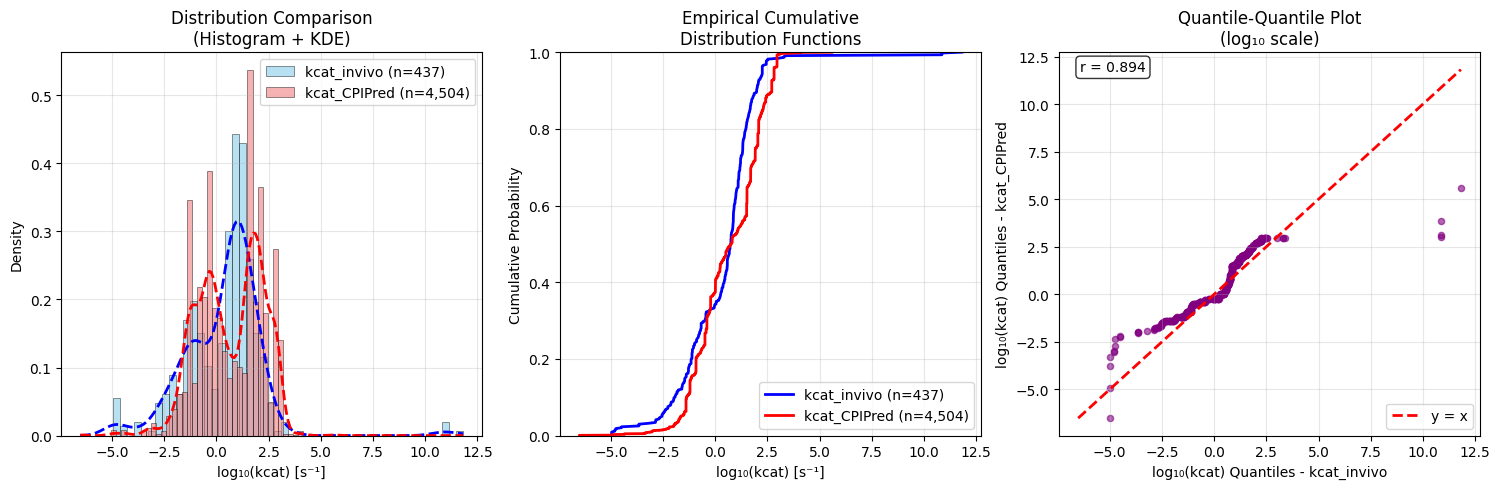

In [475]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_df, "kcat_CPIPred", label1="kcat_invivo", label2="kcat_CPIPred")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count                437             1,327          
Mean                 1.99e+09        7.23e+03       
Median               5.56e+00        1.43e+01       
Std Dev              3.19e+10        6.32e+04       
P10                  1.21e-02        1.20e-01       
P25                  1.32e-01        1.40e+00       
P75                  2.08e+01        9.20e+01       
P90                  9.64e+01        7.50e+02       
IQR (P25-P75)        2.07e+01        9.06e+01       
Geometric Mean       2.12e+00        1.19e+01       
Geometric Std        7.61e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count        

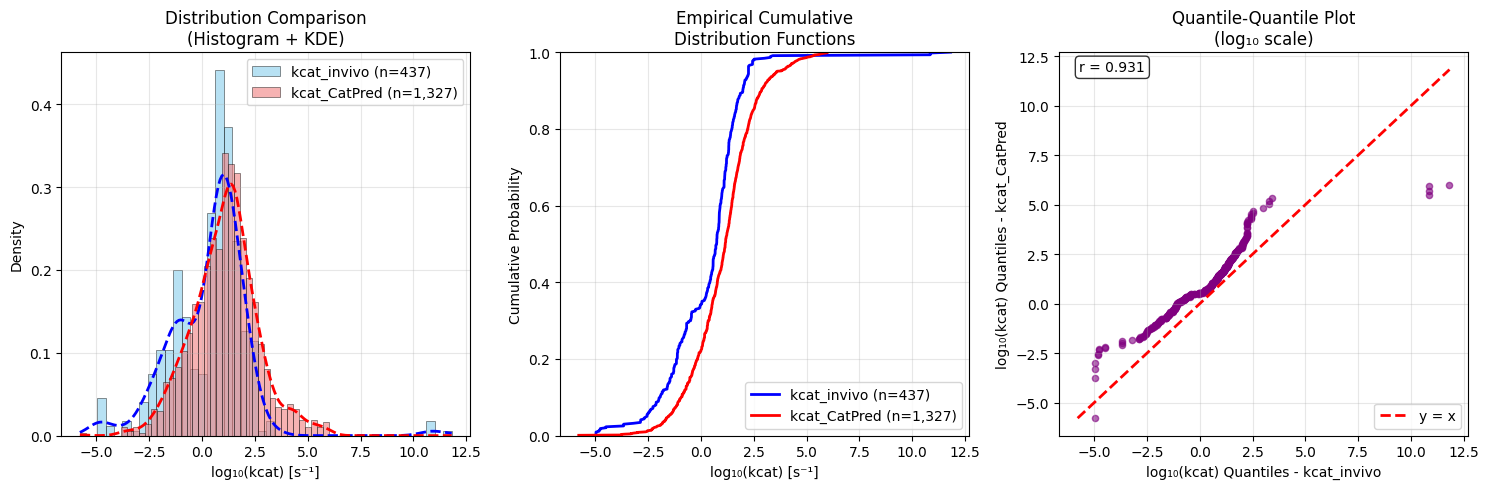

In [477]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CatPred_df, "kcat_CatPred", label1="kcat_invivo", label2="kcat_CatPred")

## ML Predicted kcats: CPI Pred

In [468]:
# Load iML1515 CPI Pred predictions
CPIPred_predictions_dir = os.path.join(processed_data_dir, "iML1515", "X06A_kinGEMs_ecoli_iML1515_predictions.csv")
CPIPred_predictions_df = pd.read_csv(CPIPred_predictions_dir)

# Drop kcat column - it's a placeholder
CPIPred_predictions_df.drop(columns=['kcat'], inplace=True)

# Get kcat by averaging predictions across 5 folds
CPIPred_predictions_df["kcat_pred"] = CPIPred_predictions_df[
    ["pred_value_0", "pred_value_1", "pred_value_2", "pred_value_3", "pred_value_4"]
].mean(axis=1)

# Keep only kcat_pred column
CPIPred_predictions_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_predictions_df = CPIPred_predictions_df[["sequence", "SMILES", "kcat_pred"]]

# There are multiple predictions for the same seq-SMILES pair, keep the largest (as done in kinGEMs)
CPIPred_predictions_df = (
    CPIPred_predictions_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [469]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_predictions_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------
Count                437             6,336          
Mean                 1.99e+09        2.94e+02       
Median               5.56e+00        5.76e+00       
Std Dev              3.19e+10        1.16e+04       
P10                  1.21e-02        1.36e+00       
P25                  1.32e-01        2.89e+00       
P75                  2.08e+01        1.16e+01       
P90                  9.64e+01        2.48e+01       
IQR (P25-P75)        2.07e+01        8.71e+00       
Geometric Mean       2.12e+00        5.85e+00       
Geometric Std        7.61e+01        3.65e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------

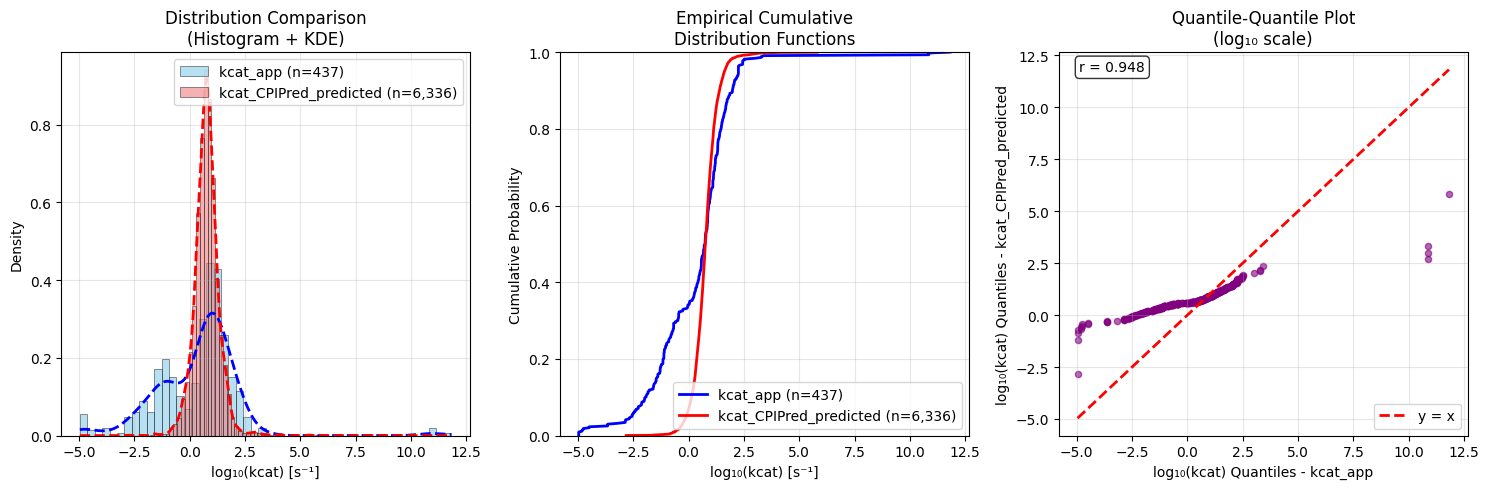

In [470]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_predictions_df, "kcat_pred", label1="kcat_app", label2="kcat_CPIPred_predicted")

## (kinGEMs tuned) ML Predicted kcats: CPI Pred

In [471]:
# Load kinGEMs tuned iML1515 CPI Pred predictions
CPIPred_tuned_dir = os.path.join(processed_data_dir, "iML1515", "df_new.csv")
CPIPred_tuned_df = pd.read_csv(CPIPred_tuned_dir)

# Keep only kcat_pred column
CPIPred_tuned_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_tuned_df = CPIPred_tuned_df[["sequence", "SMILES", "kcat_mean"]]

# Keep the largest kcat_mean for each seq-SMILES pair
CPIPred_tuned_df = (
    CPIPred_tuned_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [472]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_tuned_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count                437             6,190          
Mean                 1.99e+09        3.12e+02       
Median               5.56e+00        6.66e+00       
Std Dev              3.19e+10        1.17e+04       
P10                  1.21e-02        1.42e+00       
P25                  1.32e-01        3.08e+00       
P75                  2.08e+01        1.62e+01       
P90                  9.64e+01        5.28e+01       
IQR (P25-P75)        2.07e+01        1.31e+01       
Geometric Mean       2.12e+00        7.56e+00       
Geometric Std        7.61e+01        4.48e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count  

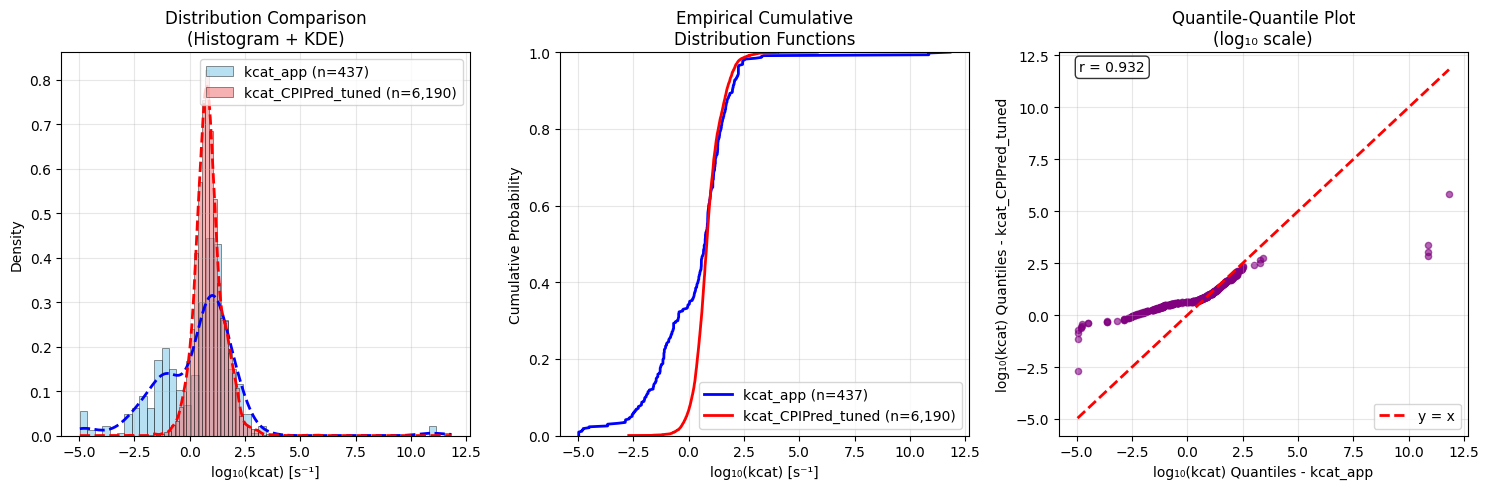

In [473]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_tuned_df, "kcat_mean", label1="kcat_app", label2="kcat_CPIPred_tuned")

# Isoenzymes

In [410]:
# Read
df_isozyme_dir = os.path.join(data_dir, "final", "kcat_app", "iml1515_isozyme_kcat_app.csv")
df_fluxomics_isozyme = pd.read_csv(df_isozyme_dir)

# Merge
df_fluxomics_isozyme = pd.merge(df_fluxomics_isozyme, df_kcat, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred   
--------------------------------------------------
Count                441             4,504          
Mean                 1.07e+10        4.03e+02       
Median               3.12e+01        5.85e+00       
Std Dev              2.07e+11        1.06e+04       
P10                  1.05e-01        4.21e-02       
P25                  2.14e+00        3.23e-01       
P75                  1.93e+02        9.00e+01       
P90                  9.15e+02        5.10e+02       
IQR (P25-P75)        1.91e+02        8.97e+01       
Geometric Mean       1.85e+01        4.52e+00       
Geometric Std        7.19e+01        3.43e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred   
--------------------------------------------------
Count        

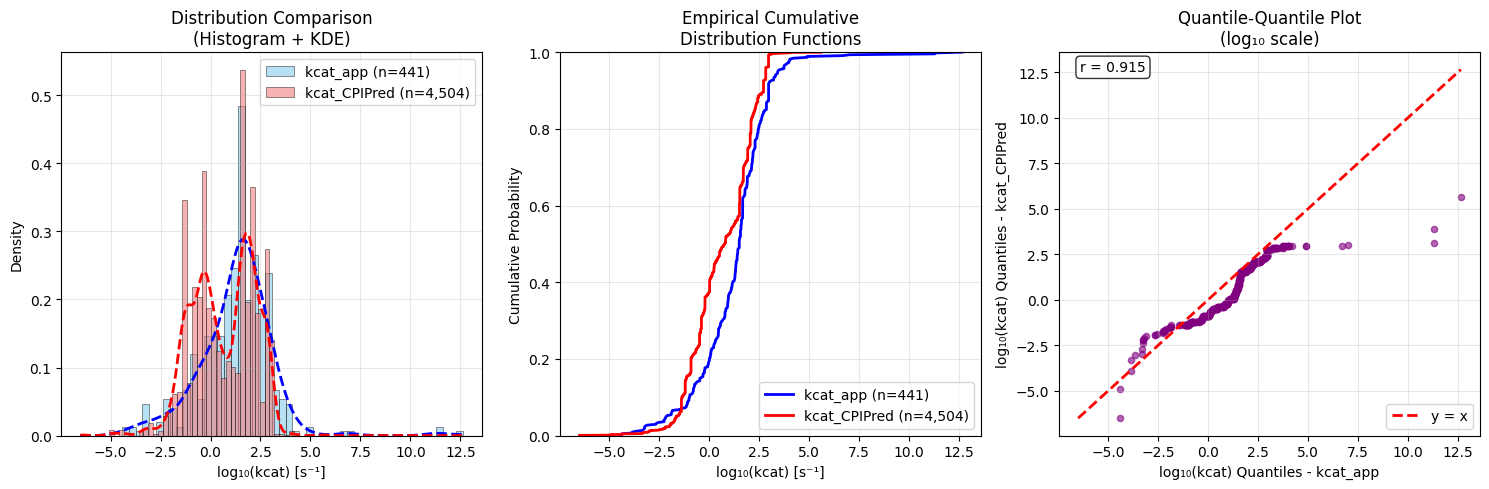

In [420]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_isozyme, "kcat_app", CPIPred_df, "kcat_CPIPred", label1="kcat_app", label2="kcat_CPIPred")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CatPred   
--------------------------------------------------
Count                441             1,327          
Mean                 1.07e+10        7.23e+03       
Median               3.12e+01        1.43e+01       
Std Dev              2.07e+11        6.32e+04       
P10                  1.05e-01        1.20e-01       
P25                  2.14e+00        1.40e+00       
P75                  1.93e+02        9.20e+01       
P90                  9.15e+02        7.50e+02       
IQR (P25-P75)        1.91e+02        9.06e+01       
Geometric Mean       1.85e+01        1.19e+01       
Geometric Std        7.19e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CatPred   
--------------------------------------------------
Count        

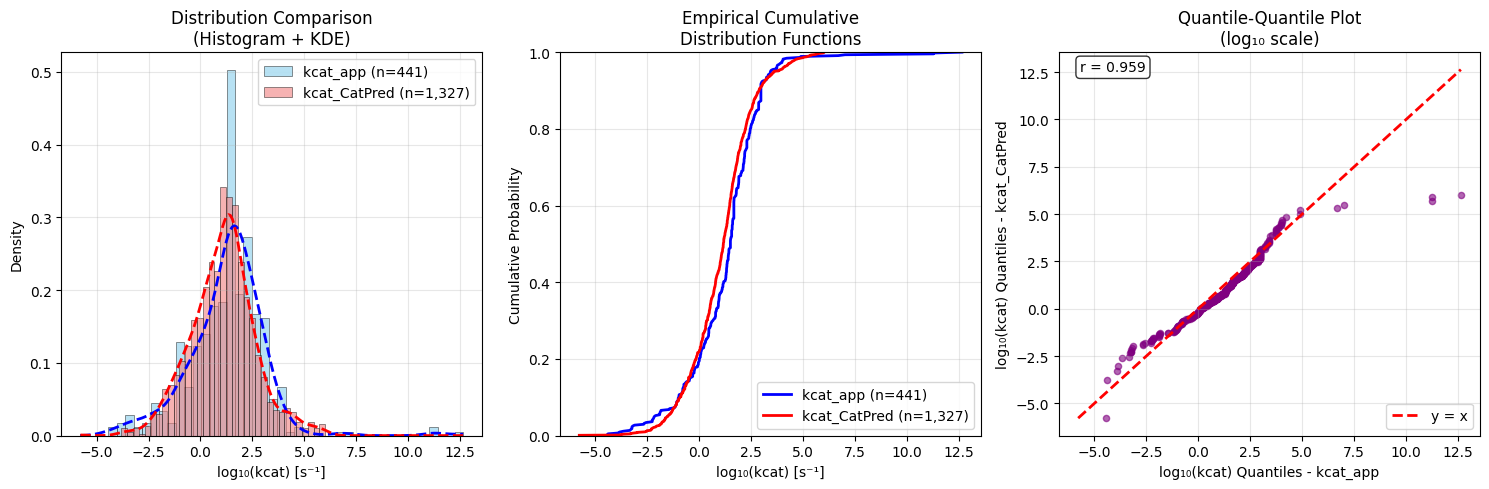

In [421]:
compare_kcat_distribution(df_fluxomics_isozyme, "kcat_app", CatPred_df, "kcat_CatPred", label1="kcat_app", label2="kcat_CatPred")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------
Count                441             6,336          
Mean                 1.07e+10        2.94e+02       
Median               3.12e+01        5.76e+00       
Std Dev              2.07e+11        1.16e+04       
P10                  1.05e-01        1.36e+00       
P25                  2.14e+00        2.89e+00       
P75                  1.93e+02        1.16e+01       
P90                  9.15e+02        2.48e+01       
IQR (P25-P75)        1.91e+02        8.71e+00       
Geometric Mean       1.85e+01        5.85e+00       
Geometric Std        7.19e+01        3.65e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------

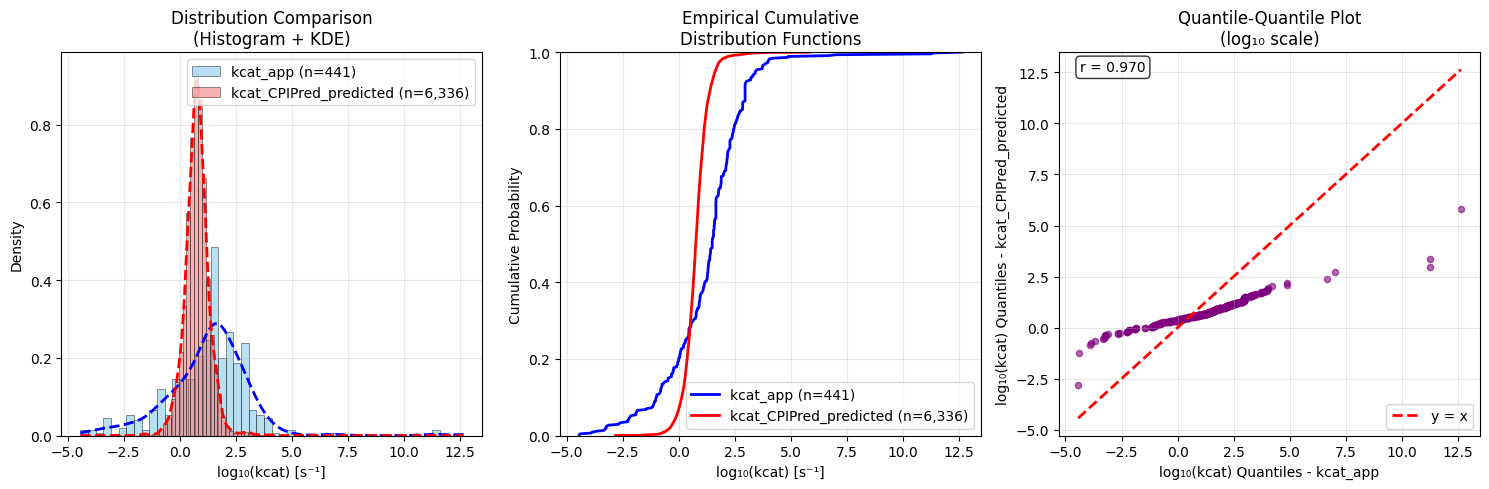

In [419]:
compare_kcat_distribution(df_fluxomics_isozyme, "kcat_app", CPIPred_predictions_df, "kcat_pred", label1="kcat_app", label2="kcat_CPIPred_predicted")
